In [ ]:
!pip install numpy pandas matplotlib scikit-learn tensorflow joblib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("Libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully!
TensorFlow version: 2.20.0


In [ ]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully!
X shape: (569, 30)
y shape: (569,)


In [ ]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
print("Features:")
print(X.columns.tolist())

Features:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [ ]:
print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


In [ ]:
print(y.value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [ ]:
print(data.target_names)

['malignant' 'benign']


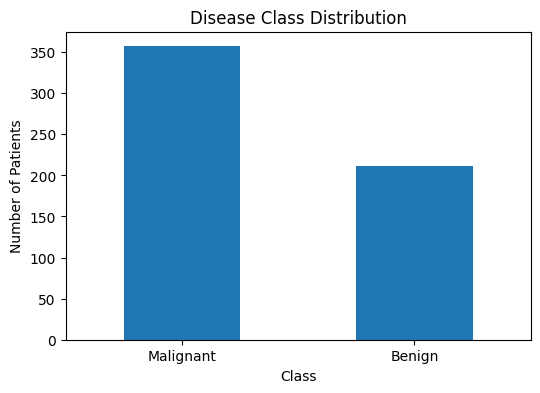

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

y.value_counts().plot(kind="bar")

plt.title("Disease Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.xticks(
    [0, 1],
    ["Malignant", "Benign"],
    rotation=0
)

plt.show()

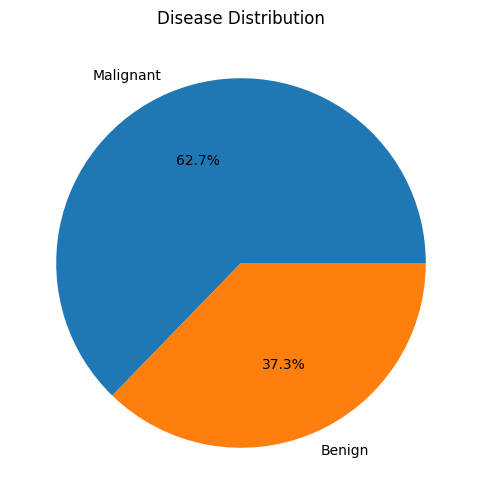

In [ ]:
plt.figure(figsize=(6, 6))

y.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Malignant", "Benign"]
)

plt.title("Disease Distribution")
plt.ylabel("")

plt.show()

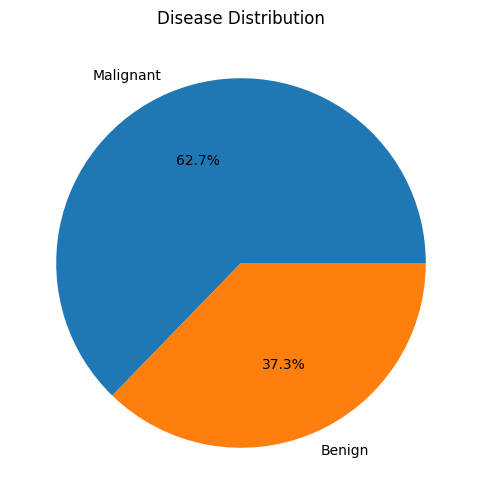

In [ ]:
plt.figure(figsize=(6, 6))

y.value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Malignant", "Benign"]
)

plt.title("Disease Distribution")
plt.ylabel("")

plt.show()

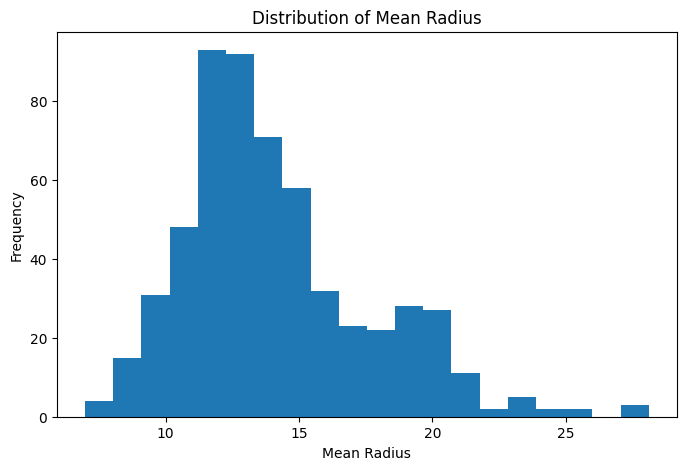

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(X["mean radius"], bins=20)

plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.show()

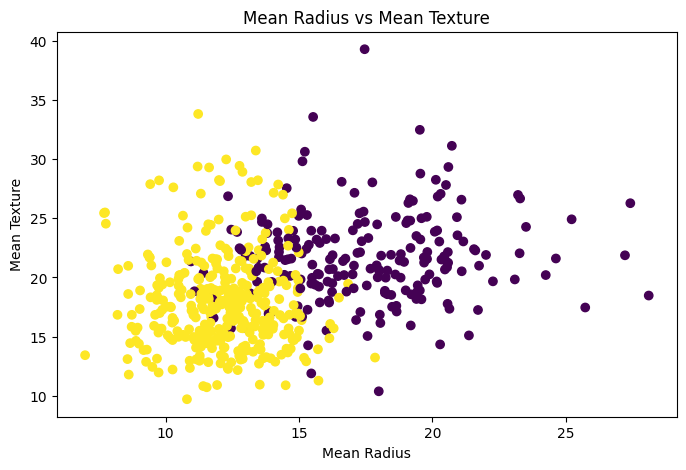

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["mean radius"],
    X["mean texture"],
    c=y
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Mean Radius vs Mean Texture")

plt.show()

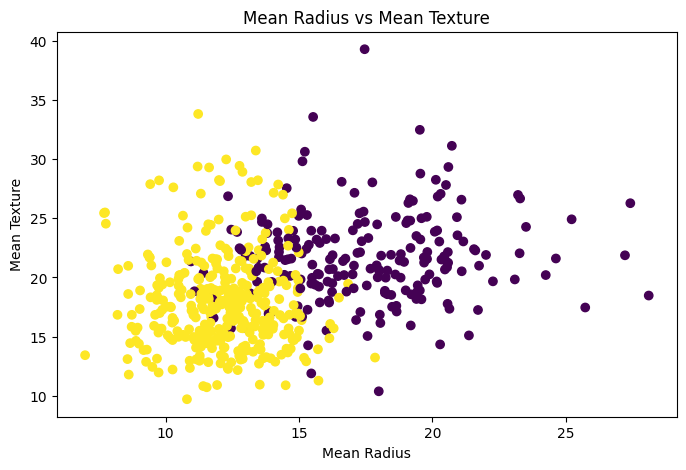

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["mean radius"],
    X["mean texture"],
    c=y
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Mean Radius vs Mean Texture")

plt.show()

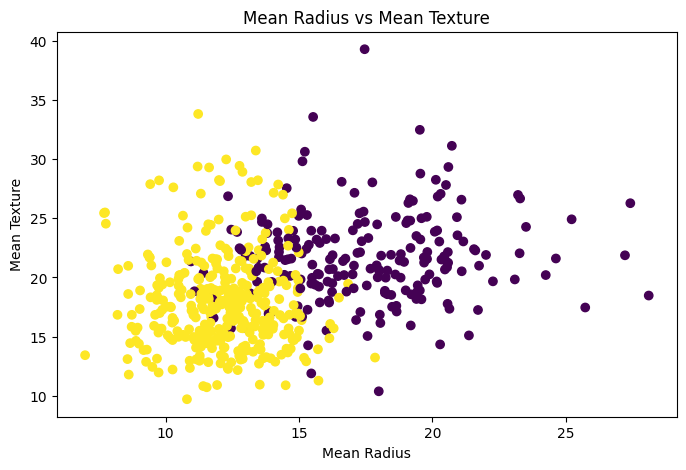

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["mean radius"],
    X["mean texture"],
    c=y
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Mean Radius vs Mean Texture")

plt.show()

In [ ]:
correlation = X.corr()

correlation.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316


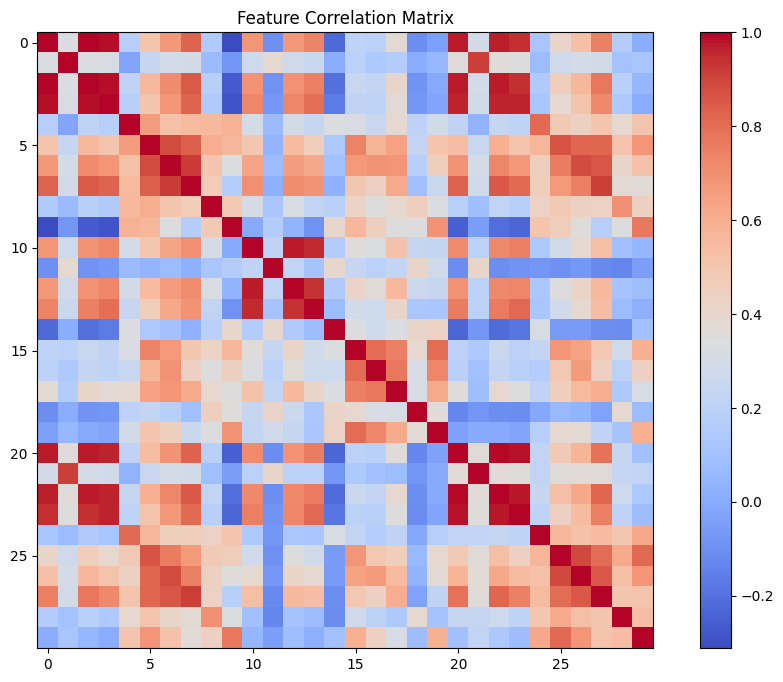

In [ ]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation, cmap="coolwarm")
plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (455, 30)
Testing samples: (114, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [ ]:
print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
model = Sequential([

    # Input + First Hidden Layer
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.30),

    # Second Hidden Layer
    Dense(32, activation="relu"),
    Dropout(0.20),

    # Third Hidden Layer
    Dense(16, activation="relu"),

    # Output Layer
    Dense(1, activation="sigmoid")
])

print("Model created successfully!")

Model created successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6896 - loss: 0.6134 - val_accuracy: 0.9451 - val_loss: 0.4707
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9258 - loss: 0.4258 - val_accuracy: 0.9451 - val_loss: 0.3201
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9286 - loss: 0.3011 - val_accuracy: 0.9560 - val_loss: 0.2119
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9396 - loss: 0.2121 - val_accuracy: 0.9560 - val_loss: 0.1549
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1535 - val_accuracy: 0.9560 - val_loss: 0.1216
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9588 - loss: 0.1367 - val_accuracy: 0.9670 - val_loss: 0.0944
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.1166 - val_accuracy: 0.9890 - val_loss: 0.0738
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.1227 - val_accuracy: 0.9890 - val_los

In [ ]:
loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Test Loss: 0.11097788065671921
Test Accuracy: 0.9649122953414917


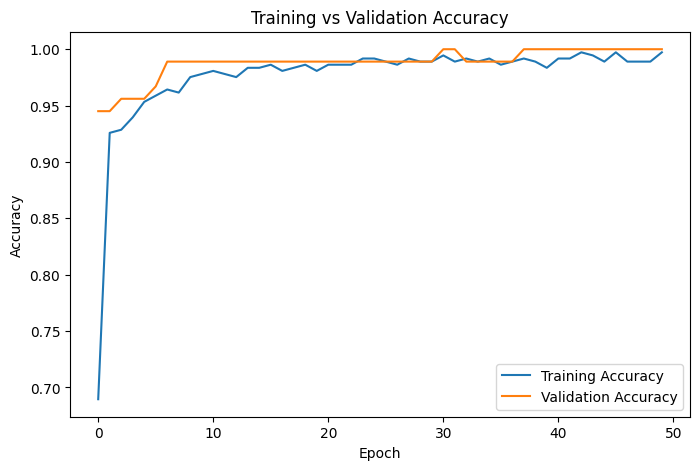

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

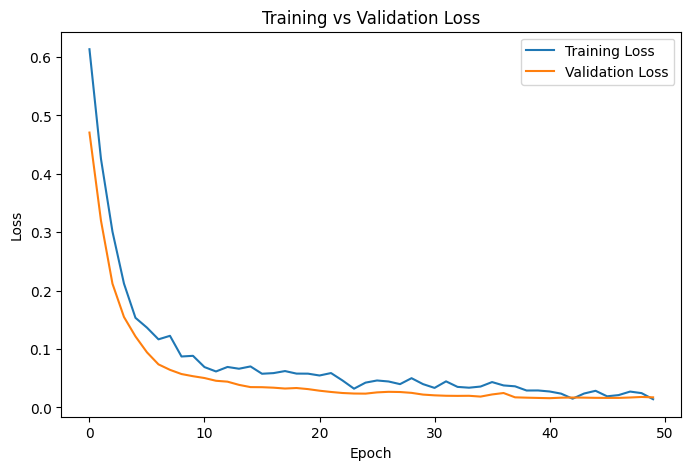

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [ ]:
y_probability = model.predict(X_test_scaled)

print(y_probability[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[3.8365747e-14]
 [9.9999982e-01]
 [1.7456818e-05]
 [3.6909048e-02]
 [1.2901959e-17]
 [9.9979442e-01]
 [9.9999946e-01]
 [4.0603436e-12]
 [1.4866988e-09]
 [2.2899431e-20]]


In [ ]:
y_pred = (y_probability >= 0.5).astype(int)

print(y_pred[:10])

[[0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)




Accuracy: 0.9649122807017544
Accuracy %: 96.49122807017544


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  1]
 [ 3 69]]


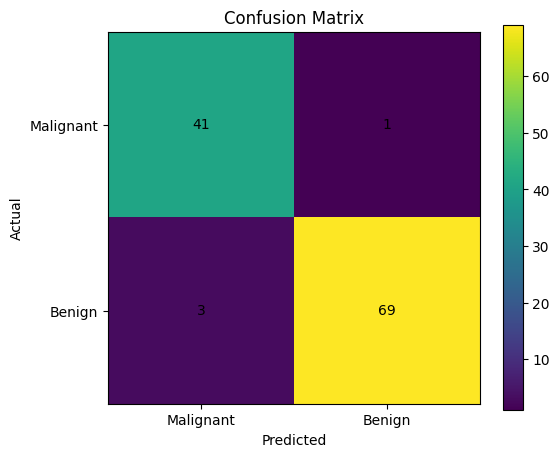

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.yticks(
    [0, 1],
    ["Malignant", "Benign"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Malignant", "Benign"]
    )
)

              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [ ]:
import os

os.makedirs("model", exist_ok=True)

print("Model folder created!")

Model folder created!


In [ ]:
model.save("model/disease_prediction_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import joblib

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model(
    "model/disease_prediction_model.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
loaded_scaler = joblib.load(
    "model/scaler.pkl"
)

print("Scaler loaded successfully!")

Scaler loaded successfully!


In [ ]:
test_predictions = loaded_model.predict(
    X_test_scaled
)

test_predictions = (
    test_predictions >= 0.5
).astype(int)

print(test_predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]]


In [ ]:
def predict_disease(input_data):

    input_data = np.array(input_data)

    input_data = input_data.reshape(1, -1)

    scaled_data = loaded_scaler.transform(
        input_data
    )

    probability = loaded_model.predict(
        scaled_data,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        result = "Benign"
    else:
        result = "Malignant"

    return result, probability

In [ ]:
sample = X_test.iloc[0].values

result, probability = predict_disease(sample)

print("Prediction:", result)
print("Probability:", probability)

Prediction: Malignant
Probability: 3.8365758e-14


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
sample_index = 0

actual = y_test.iloc[sample_index]

sample = X_test.iloc[sample_index].values

result, probability = predict_disease(sample)

actual_label = (
    "Benign" if actual == 1
    else "Malignant"
)

print("Actual:", actual_label)
print("Predicted:", result)
print("Probability:", probability)

Actual: Malignant
Predicted: Malignant
Probability: 3.8365758e-14


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
for i in range(10):

    sample = X_test.iloc[i].values

    result, probability = predict_disease(sample)

    actual = (
        "Benign"
        if y_test.iloc[i] == 1
        else "Malignant"
    )

    print(
        f"Patient {i+1}: "
        f"Actual={actual}, "
        f"Predicted={result}, "
        f"Probability={probability:.2f}"
    )

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Patient 1: Actual=Malignant, Predicted=Malignant, Probability=0.00
Patient 2: Actual=Benign, Predicted=Benign, Probability=1.00
Patient 3: Actual=Malignant, Predicted=Malignant, Probability=0.00


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Patient 4: Actual=Benign, Predicted=Malignant, Probability=0.04
Patient 5: Actual=Malignant, Predicted=Malignant, Probability=0.00
Patient 6: Actual=Benign, Predicted=Benign, Probability=1.00


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Patient 7: Actual=Benign, Predicted=Benign, Probability=1.00
Patient 8: Actual=Malignant, Predicted=Malignant, Probability=0.00
Patient 9: Actual=Malignant, Predicted=Malignant, Probability=0.00
Patient 10: Actual=Malignant, Predicted=Malignant, Probability=0.00


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import tensorflow as tf
import joblib

# Load trained model
model = tf.keras.models.load_model(
    "model/disease_prediction_model.keras"
)

# Load scaler
scaler = joblib.load(
    "model/scaler.pkl"
)

# Page configuration
st.set_page_config(
    page_title="Disease Prediction",
    page_icon="🩺",
    layout="wide"
)

# Title
st.title("🩺 Disease Prediction using Deep Learning")

st.write(
    "Enter the patient feature values below "
    "to generate a model prediction."
)

st.divider()

# Feature names
feature_names = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "smoothness error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension"
]

# Create input fields
inputs = []

for feature in feature_names:

    value = st.number_input(
        feature,
        value=0.0,
        format="%.4f"
    )

    inputs.append(value)

st.divider()

# Prediction button
if st.button("🔮 Predict Disease"):

    input_data = np.array(inputs).reshape(1, -1)

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Prediction
    probability = model.predict(
        input_scaled,
        verbose=0
    )[0][0]

    # Display result
    if probability >= 0.5:

        st.success(
            "Prediction: Benign"
        )

    else:

        st.error(
            "Prediction: Malignant"
        )

    st.write(
        f"Model probability: {probability:.4f}"
    )

st.divider()

st.caption(
    "Educational project only. "
    "This application is not a medical diagnostic tool."
)

Writing app.py


In [ ]:
!pip install streamlit

In [ ]:
!streamlit run app.py



2026-09-28 14:55:29.450 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.11.118.189:8501



In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.datasets import load_breast_cancer


# --------------------------------------------------
# 1. LOAD MODEL AND SCALER
# --------------------------------------------------

model = tf.keras.models.load_model(
    "model/disease_prediction_model.keras"
)

scaler = joblib.load(
    "model/scaler.pkl"
)


# --------------------------------------------------
# 2. LOAD DATASET
# --------------------------------------------------

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)


# --------------------------------------------------
# 3. PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Deep Learning Disease Prediction",
    page_icon="🩺",
    layout="wide"
)


# --------------------------------------------------
# 4. TITLE
# --------------------------------------------------

st.title("🩺 Disease Prediction using Deep Learning")

st.write(
    "Artificial Neural Network based classification system"
)

st.divider()


# --------------------------------------------------
# 5. SIDEBAR
# --------------------------------------------------

st.sidebar.header("Project Information")

st.sidebar.write(
    """
    **Model:** Artificial Neural Network

    **Framework:** TensorFlow / Keras

    **Dataset:** Breast Cancer Wisconsin

    **Features:** 30

    **Task:** Binary Classification
    """
)


# --------------------------------------------------
# 6. SELECT SAMPLE
# --------------------------------------------------

st.subheader("Select Patient Sample")

sample_number = st.number_input(
    "Enter sample number",
    min_value=0,
    max_value=len(X) - 1,
    value=0,
    step=1
)


# --------------------------------------------------
# 7. DISPLAY SAMPLE
# --------------------------------------------------

sample = X.iloc[sample_number].values

st.write(
    "Selected sample features:"
)

sample_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Value": sample
    }
)

st.dataframe(
    sample_df,
    use_container_width=True
)


# --------------------------------------------------
# 8. PREDICTION
# --------------------------------------------------

if st.button("🔮 Predict Disease"):

    # Reshape
    input_data = np.array(sample).reshape(1, -1)

    # Scale
    input_scaled = scaler.transform(
        input_data
    )

    # Predict
    probability = model.predict(
        input_scaled,
        verbose=0
    )[0][0]

    # Convert probability to class
    if probability >= 0.5:
        prediction = 1
        prediction_label = "Benign"
    else:
        prediction = 0
        prediction_label = "Malignant"


    # --------------------------------------------------
    # 9. DISPLAY RESULT
    # --------------------------------------------------

    st.subheader("Prediction Result")

    if prediction == 1:

        st.success(
            f"Prediction: {prediction_label}"
        )

    else:

        st.error(
            f"Prediction: {prediction_label}"
        )


    st.metric(
        "Model Probability",
        f"{probability:.2%}"
    )


    # --------------------------------------------------
    # 10. ACTUAL VALUE
    # --------------------------------------------------

    actual = y.iloc[sample_number]

    if actual == 1:
        actual_label = "Benign"
    else:
        actual_label = "Malignant"


    st.write(
        f"**Actual Class:** {actual_label}"
    )


    # --------------------------------------------------
    # 11. CHECK PREDICTION
    # --------------------------------------------------

    if prediction == actual:

        st.info(
            "The model prediction matches "
            "the dataset label."
        )

    else:

        st.warning(
            "The model prediction differs "
            "from the dataset label."
        )


# --------------------------------------------------
# 12. DISCLAIMER
# --------------------------------------------------

st.divider()

st.caption(
    "Educational Deep Learning project only. "
    "This application is not a medical diagnostic tool."
)

In [ ]:
!streamlit run app.py

In [ ]:
st.divider()

st.subheader("📊 Model Performance")

col1, col2, col3 = st.columns(3)

col1.metric(
    "Test Accuracy",
    f"{accuracy * 100:.2f}%"
)

col2.metric(
    "Training Samples",
    len(X_train_scaled)
)

col3.metric(
    "Testing Samples",
    len(X_test_scaled)
)

In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ==================================================
# 1. LOAD DATASET
# ==================================================

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)


# ==================================================
# 2. TRAIN / TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==================================================
# 3. LOAD MODEL AND SCALER
# ==================================================

model = tf.keras.models.load_model(
    "model/disease_prediction_model.keras"
)

scaler = joblib.load(
    "model/scaler.pkl"
)


# ==================================================
# 4. SCALE TEST DATA
# ==================================================

X_test_scaled = scaler.transform(X_test)


# ==================================================
# 5. GENERATE TEST PREDICTIONS
# ==================================================

probabilities = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = (
    probabilities >= 0.5
).astype(int).flatten()


# ==================================================
# 6. CALCULATE METRICS
# ==================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

cm = confusion_matrix(
    y_test,
    y_pred
)


# ==================================================
# 7. PAGE CONFIGURATION
# ==================================================

st.set_page_config(
    page_title="Disease Prediction",
    page_icon="🩺",
    layout="wide"
)


# ==================================================
# 8. TITLE
# ==================================================

st.title(
    "🩺 Disease Prediction using Deep Learning"
)

st.write(
    "Artificial Neural Network based "
    "Binary Classification System"
)

st.divider()


# ==================================================
# 9. SIDEBAR
# ==================================================

st.sidebar.title("Navigation")

page = st.sidebar.radio(
    "Select Page",
    [
        "Prediction",
        "Model Performance",
        "Dataset"
    ]
)


# ==================================================
# 10. PREDICTION PAGE
# ==================================================

if page == "Prediction":

    st.header("🔮 Disease Prediction")

    sample_number = st.number_input(
        "Select Patient Sample",
        min_value=0,
        max_value=len(X) - 1,
        value=0,
        step=1
    )

    sample = X.iloc[
        sample_number
    ].values

    st.subheader(
        "Patient Features"
    )

    sample_df = pd.DataFrame({
        "Feature": X.columns,
        "Value": sample
    })

    st.dataframe(
        sample_df,
        use_container_width=True
    )

    if st.button(
        "🔮 Predict Disease"
    ):

        input_data = np.array(
            sample
        ).reshape(1, -1)

        input_scaled = scaler.transform(
            input_data
        )

        probability = model.predict(
            input_scaled,
            verbose=0
        )[0][0]

        if probability >= 0.5:

            prediction = 1
            prediction_label = "Benign"

            st.success(
                "Prediction: Benign"
            )

        else:

            prediction = 0
            prediction_label = "Malignant"

            st.error(
                "Prediction: Malignant"
            )

        st.metric(
            "Prediction Probability",
            f"{probability:.2%}"
        )

        actual = y.iloc[
            sample_number
        ]

        actual_label = (
            "Benign"
            if actual == 1
            else "Malignant"
        )

        st.write(
            f"**Actual Class:** {actual_label}"
        )


# ==================================================
# 11. MODEL PERFORMANCE PAGE
# ==================================================

elif page == "Model Performance":

    st.header(
        "📊 Model Performance"
    )

    # Metrics
    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Accuracy",
        f"{accuracy * 100:.2f}%"
    )

    col2.metric(
        "Precision",
        f"{precision * 100:.2f}%"
    )

    col3.metric(
        "Recall",
        f"{recall * 100:.2f}%"
    )

    col4.metric(
        "F1 Score",
        f"{f1 * 100:.2f}%"
    )

    st.divider()

    # Confusion Matrix
    st.subheader(
        "Confusion Matrix"
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            "Actual Malignant",
            "Actual Benign"
        ],
        columns=[
            "Predicted Malignant",
            "Predicted Benign"
        ]
    )

    st.dataframe(
        cm_df,
        use_container_width=True
    )

    st.write(
        "The confusion matrix shows how "
        "the model's predictions compare "
        "with the actual classes."
    )


# ==================================================
# 12. DATASET PAGE
# ==================================================

elif page == "Dataset":

    st.header(
        "📋 Dataset Information"
    )

    col1, col2, col3 = st.columns(3)

    col1.metric(
        "Total Samples",
        X.shape[0]
    )

    col2.metric(
        "Features",
        X.shape[1]
    )

    col3.metric(
        "Classes",
        y.nunique()
    )

    st.subheader(
        "Dataset Preview"
    )

    st.dataframe(
        X.head(10),
        use_container_width=True
    )

    st.subheader(
        "Class Distribution"
    )

    st.write(
        y.value_counts()
    )


# ==================================================
# 13. DISCLAIMER
# ==================================================

st.divider()

st.caption(
    "Educational Deep Learning project only. "
    "This application is not a medical diagnostic tool."
)